# Non-parametric Least Squares Solution with Radial Basis Kernel Function

In this exercise you will see how we can implement a radial basis kernel funciton linear model and provide a solution via a non-parametric least squares. Note how we duspense with the usage of weights altogether on the expense of dealing with vector Kt which involves matrix inverison and is calculated once for a static dataset.


**Learning Outcomes**

1. Implement the non parametric kernel least square solution with radial basis kernel funciton
2. Apply the implemented solution on a synthetic data and examine the resultant RMSE


In [1]:
%matplotlib inline

In [2]:
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import pandas as pd
import time

generate the data

In [6]:
def generateData(w_, x1, noise=0, linear=True ):
    # Generates target data given some noise and input matrix X
    
    x0 = np.ones((x1.shape[0],))                  # the intercept
    X  = np.array([x0, x1]).T                     # design matrix with intercept

    if linear==True:
        # Generating linearly separable data (of the form y = w0 + w1*x1)
        y  = (X.dot(w_)).T                        # get the target value
    else:
        # Generating non-linearly separable data of the form y = cos(x1) - no weights
        y  = np.cos(x1)

    # Sampling from a normal distribution with mean = y and variance = "noise"
    t  = np.random.normal(y,noise)                # add noise to the target to see the effect on the MSE
    return y, t, X


## Generate the data first

### Choose between linear and non-linear data
Note how non-parametric RBF least squares is capable of producing no-linear data, while the standard parametric least squares on linear model is not. 
In a sense this is the most important hyper parameter that allows us to change the shape of our data and examine the model capabilities .

In [7]:
#linear= True
linear= False

In [8]:
# w_ is the original linear model weights to generate the data from and to compare later with predicted weights w
w_    = np.array([10, 2]).T
noise = .1
num   = 300 # try increase num to see how long it will take to find the solution

# choose between linear and nonlinear data
rnge    = 10
x_train = np.linspace(-rnge, rnge, num=num)             # this sampling uniformly from the x axis
y_train, t_train, X_train = generateData(w_, x_train, noise=noise, linear=linear)    # try with and without noise 

print(X_train.shape)
print(t_train.shape)

(300, 2)
(300,)


## RBF Kernel Least Squares Solutions with Regularisation 

In [9]:
def rbf_kernel(xi, X, σ): 
    # efficient; takes advantage of broadcasting: X-xi is vector-element
    k = np.exp(-(np.sum((X-xi)**2,1))/σ**2)
    return k

# generate RBF basis
def rbf_K(X, σ): 
    # X is a design matrix
    N = X.shape[0] # dimension for number of data points
    K = np.zeros((N,N))  # Initiating an empty NxN matrix
    for i, xi in enumerate(X):
        # Loop through every row in the design matrix and
        # work out the similarity of that row with every
        # other row in the design matrix
        K[i] = rbf_kernel(xi, X, σ=σ)
    print(f'K is of shape: {K.shape}')
    return K#Φ

def rbf_Kt(K, t, λ=0.000001):  # Kt should be calculated once as it does not change
    # Moving the target values into the feature space?
    # for kernel Least Squares Solution
    # λ is a regularisation constant
    I  = np.eye((K.shape[0]))
    K  = inv(K + λ*I)
    Kt = K.dot(t)
    print('K  dim =',K.shape)
    print('Kt dim =',Kt.shape)
    return Kt


In [10]:
# σ is an important hyper paramter that has effect on the quality of the solution
σ  = .1 # 5  # try different values 
K  = rbf_K (X_train, σ=σ)
Kt = rbf_Kt(K, t_train)


K is of shape: (300, 300)
K  dim = (300, 300)
Kt dim = (300,)


## Non-parametric solution
Note that there is no $\boldsymbol{w}$ that we are dealing with anymore, we are dealing directly with the predictions y

In [11]:
def rbf_y(xi, X, σ, Kt):
    # determining the y-value for a specific data point
    k = rbf_kernel(xi, X, σ)
    #print(k.shape)
    y = k.dot(Kt)  # technically k-transpose, but k is symmetrical
    return y

def rbf_ys(X, σ, Kt):
    # determining the y-values for the entire matrix by
    # iterating row-by-row
    ys = np.zeros(X.shape[0])
    for i, xi in enumerate(X):
        ys[i] = rbf_y(xi, X, σ, Kt)
    #print(ys, t)
    return ys


## Now apply the Least Squares on the Generated Dataset

Now let us try it!

In [23]:
def apply_rbf_LS(X,t):
    
    start = time.time()
    ys = rbf_ys(X, σ, Kt)                        # predict using Kt solution
    exect = np.round(time.time() - start,5)
    
    RMSE = np.sqrt(((t - ys)**2).sum()/len(t))   # get the Sqrt(Mean Sum of Squared Error)    
    return ys, RMSE, exect


y_train_predict, RMSE_train, exect_train = apply_rbf_LS(X_train,t_train)      # non-parametric least squares
print(exect_train)
print(RMSE_train)

0.02054
1.585440798843506e-06


## Now examine RMSE for Testing


In [24]:
x_test = np.linspace(-rnge, rnge, num=num) # shift the range hence different test data is generated
y_test_real, t_test_real, X_test     = generateData(w_, x_test, noise=noise, linear=linear)
y_test_pred, RMSE_test,   exect_test = apply_rbf_LS(X_test,y_test_real)      # non-parametric least squares
print(exect_train)
print(RMSE_test)

0.02054
0.10888260935955121


## Visualise 
both attributes x1 and x2 in 2d, we may want to create a better visualisation by plotting in 3d (x1, x2, y)

note how the data is distributed around the line

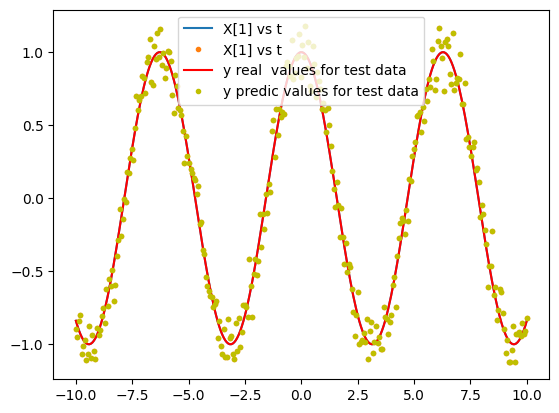

In [22]:
plt.plot(x_train, y_train,   '-', label='X[1] vs t')
plt.plot(x_train, t_train,   '.', label='X[1] vs t')

plt.plot(x_test,  y_test_real, '-r', label='y real  values for test data')
plt.plot(x_test,  y_test_pred, '.y', label='y predic values for test data')
plt.legend()

## Your turn

Compare the quality of the solution with a standard least squares solution.